Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 99ms/step - loss: 0.1495 - val_loss: 0.0898
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 95ms/step - loss: 0.0858 - val_loss: 0.0820
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 89s 109ms/step - loss: 0.0812 - val_loss: 0.0789
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 77s 98ms/step - loss: 0.0788 - val_loss: 0.0770
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 95ms/step - loss: 0.0771 - val_loss: 0.0757
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 96ms/step - loss: 0.0760 - val_loss: 0.0747
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 91ms/step - loss: 0.0751 - val_loss: 0.0739
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 104ms/step - loss: 0.0743 - val_loss: 0.0732
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 112ms/step - loss: 0.0737 - val_loss: 0.0728
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 47s 100ms/step - loss: 0.0731 - val_loss: 0.0722
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


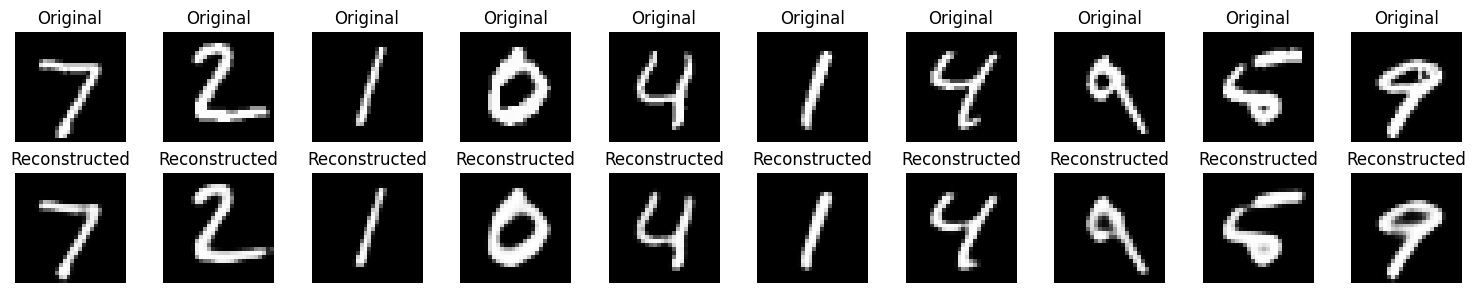

In [2]:
#Kalyani_23070521036
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

# 1. Load and Normalize MNIST Dataset (Unsupervised: Discard Labels)
(X_train, _), (X_test, _) = mnist.load_data()
X_train = X_train.astype('float32').reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.astype('float32').reshape(-1, 28, 28, 1) / 255.0

# 2. Build Encoder-Decoder Architecture
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)  # Bottleneck: (7, 7, 8)

# Decoder
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

# 3. Compile Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 4. Train Autoencoder (Input == Output)
autoencoder.fit(
    X_train, X_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test, X_test),
    verbose=1
)

# 5. Reconstruct Test Images
decoded_imgs = autoencoder.predict(X_test[:10])

# 6. Visualize Original vs Reconstructed Images
n = 10
plt.figure(figsize=(15, 3))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.tight_layout()
plt.show()